In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset, WeightedRandomSampler
from torchvision import transforms, datasets, models
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
import numpy as np

# Reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch version: 2.6.0
Using device: cuda
GPU: Tesla T4


In [2]:
class CLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img = np.array(img)
        if len(img.shape) == 3:
            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            lab[:, :, 0] = self.clahe.apply(lab[:, :, 0])
            img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img)

class GaussianNoise(object):
    def __init__(self, std=0.02):
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std

print("Custom transforms defined ✓")

Custom transforms defined ✓


In [3]:
TRAIN_DIR = '/home/sagemaker-user/dataset_classification/Training'
TEST_DIR  = '/home/sagemaker-user/dataset_classification/Testing'
IMG_SIZE  = 224

train_transforms = transforms.Compose([
    CLAHE(clip_limit=2.0),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    GaussianNoise(std=0.02)
])

test_transforms = transforms.Compose([
    CLAHE(clip_limit=2.0),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms defined ✓")

Transforms defined ✓


In [4]:
# Load split indices
with open('/home/sagemaker-user/NeuroVision/split_indices.json', 'r') as f:
    split_data = json.load(f)

train_idx = split_data['train']
val_idx   = split_data['val']
test_idx  = split_data['test']

# Load using same method as custom_cnn to guarantee index alignment
base_train  = datasets.ImageFolder(TRAIN_DIR)
base_test   = datasets.ImageFolder(TEST_DIR)
targets     = base_train.targets + base_test.targets
class_names = base_train.classes
print(f"Classes: {class_names}")
print(f"Total samples: {len(targets)}")

# Build subsets with transforms
train_dataset = Subset(ConcatDataset([
    datasets.ImageFolder(TRAIN_DIR, transform=train_transforms),
    datasets.ImageFolder(TEST_DIR,  transform=train_transforms)
]), train_idx)

val_dataset = Subset(ConcatDataset([
    datasets.ImageFolder(TRAIN_DIR, transform=test_transforms),
    datasets.ImageFolder(TEST_DIR,  transform=test_transforms)
]), val_idx)

test_dataset = Subset(ConcatDataset([
    datasets.ImageFolder(TRAIN_DIR, transform=test_transforms),
    datasets.ImageFolder(TEST_DIR,  transform=test_transforms)
]), test_idx)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# Weighted sampler
train_targets = [targets[i] for i in train_idx]
class_counts  = Counter(train_targets)
weights       = [1.0 / class_counts[t] for t in train_targets]
sampler       = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# DataLoaders
BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders ready ✓")

Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Total samples: 3264

Train: 2284 | Val: 490 | Test: 490
DataLoaders ready ✓


In [5]:
# Class weights
class_counts_all = Counter(targets)
total            = len(targets)
class_weights    = torch.tensor(
    [total / class_counts_all[i] for i in range(4)],
    dtype=torch.float
).to(device)
print(f"Class weights: { {class_names[i]: round(class_weights[i].item(), 3) for i in range(4)} }")

# EfficientNet-B0 with pretrained ImageNet weights
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Replace classifier head
model.classifier = nn.Sequential(
    nn.Dropout(p=0.6),
    nn.Linear(in_features=1280, out_features=4, bias=True)
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Class weights: {'glioma_tumor': 3.525, 'meningioma_tumor': 3.483, 'no_tumor': 6.528, 'pituitary_tumor': 3.623}


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/sagemaker-user/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 23.7MB/s]

Trainable parameters: 4,012,672


In [6]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print("Loss, optimizer, scheduler ready ✓")

Loss, optimizer, scheduler ready ✓


In [7]:
NUM_EPOCHS      = 50
EARLY_STOP      = 10
best_val_loss   = float('inf')
no_improve      = 0
best_model_path = '/home/sagemaker-user/NeuroVision/efficientnet_best.pth'

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    running_loss, correct, total_seen = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total_seen   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total_seen

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            val_loss      += loss.item()
            _, predicted   = outputs.max(1)
            val_correct   += predicted.eq(labels).sum().item()
            val_total     += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = 100. * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), best_model_path)
        saved = "← saved"
    else:
        no_improve += 1
        saved = ""

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}% | "
          f"No improve: {no_improve}/{EARLY_STOP} {saved}")

    if no_improve >= EARLY_STOP:
        print(f"\nEarly stopping triggered at epoch {epoch+1} ✓")
        break

print("\nTraining complete ✓")
print(f"Best val loss: {best_val_loss:.4f}")

Epoch [01/50] Train Loss: 1.0144 Acc: 59.2% | Val Loss: 1.1235 Acc: 43.1% | No improve: 0/10 ← saved
Epoch [02/50] Train Loss: 0.4810 Acc: 81.7% | Val Loss: 0.9895 Acc: 52.9% | No improve: 0/10 ← saved
Epoch [03/50] Train Loss: 0.3167 Acc: 87.0% | Val Loss: 1.0704 Acc: 58.2% | No improve: 1/10 
Epoch [04/50] Train Loss: 0.2144 Acc: 91.9% | Val Loss: 0.6928 Acc: 68.8% | No improve: 0/10 ← saved
Epoch [05/50] Train Loss: 0.1636 Acc: 93.9% | Val Loss: 0.9842 Acc: 65.1% | No improve: 1/10 
Epoch [06/50] Train Loss: 0.1382 Acc: 95.0% | Val Loss: 0.8069 Acc: 68.6% | No improve: 2/10 
Epoch [07/50] Train Loss: 0.1303 Acc: 95.5% | Val Loss: 0.6478 Acc: 73.5% | No improve: 0/10 ← saved
Epoch [08/50] Train Loss: 0.1032 Acc: 96.3% | Val Loss: 0.5283 Acc: 79.8% | No improve: 0/10 ← saved
Epoch [09/50] Train Loss: 0.0905 Acc: 96.9% | Val Loss: 0.4801 Acc: 81.8% | No improve: 0/10 ← saved
Epoch [10/50] Train Loss: 0.0668 Acc: 97.6% | Val Loss: 0.6338 Acc: 79.6% | No improve: 1/10 
Epoch [11/50] Trai

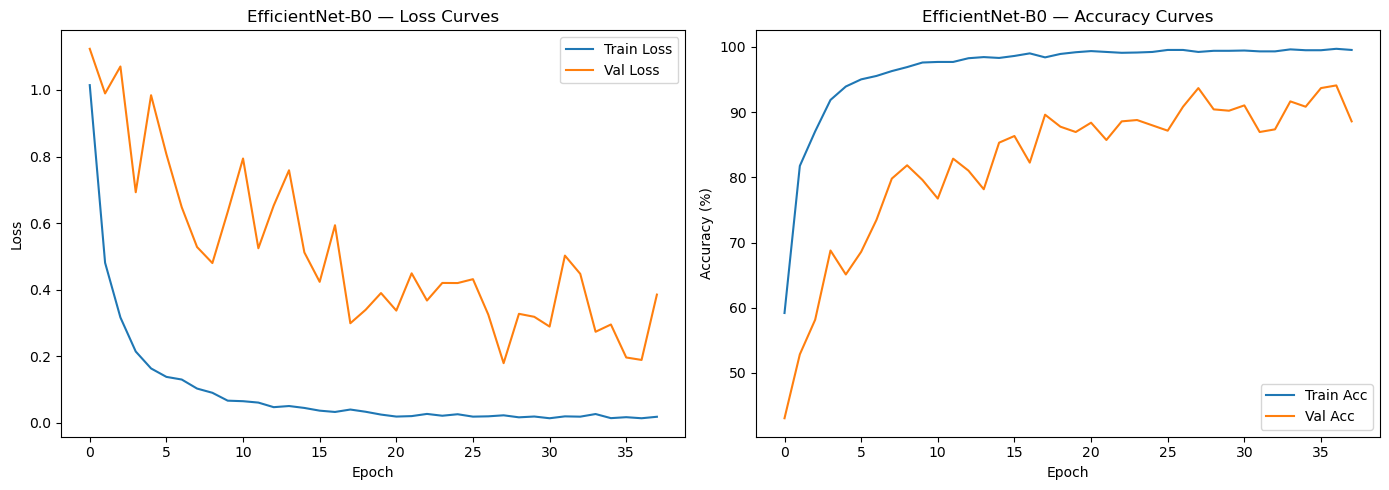

Training curves saved ✓


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('EfficientNet-B0 — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs,   label='Val Acc')
ax2.set_title('EfficientNet-B0 — Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('/home/sagemaker-user/NeuroVision/efficientnet_training_curves.png', dpi=150)
plt.show()
print("Training curves saved ✓")

In [9]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
test_acc    = 100. * np.sum(all_preds == all_labels) / len(all_labels)

print("=" * 50)
print("EFFICIENTNET-B0 — FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"Test Accuracy:    {test_acc:.2f}%")
print(f"Weighted F1:      {weighted_f1:.4f}")
print("=" * 50)

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.91      0.85      0.88       139
meningioma_tumor       0.88      0.86      0.87       141
        no_tumor       0.84      0.96      0.89        75
 pituitary_tumor       0.96      0.97      0.96       135

        accuracy                           0.90       490
       macro avg       0.90      0.91      0.90       490
    weighted avg       0.90      0.90      0.90       490

EFFICIENTNET-B0 — FINAL RESULTS SUMMARY
Test Accuracy:    90.20%
Weighted F1:      0.9017


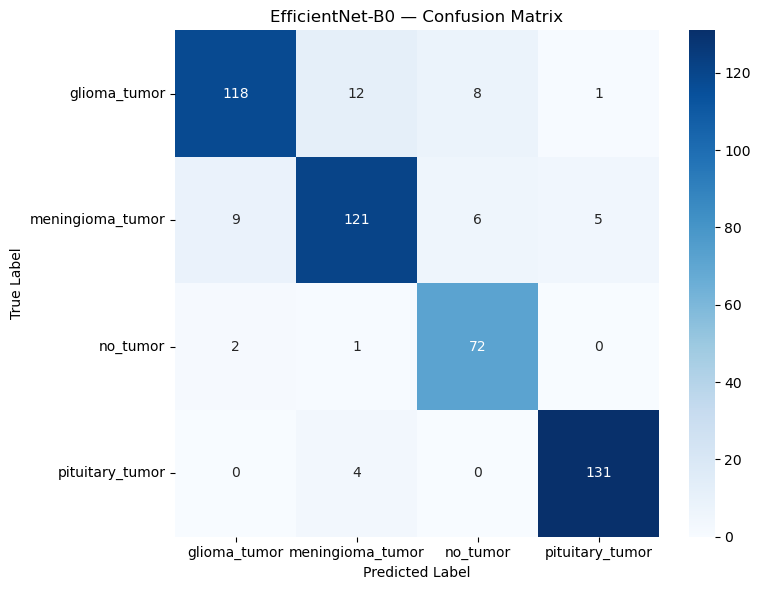

In [10]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('EfficientNet-B0 — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/home/sagemaker-user/NeuroVision/efficientnet_confusion_matrix.png', dpi=150)
plt.show()

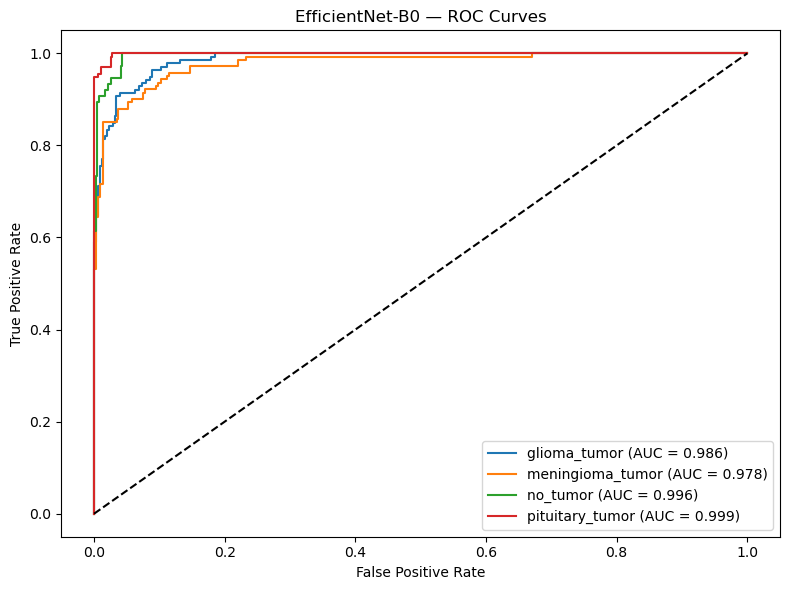

Weighted ROC-AUC: 0.9889


In [11]:
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    auc = roc_auc_score(all_labels_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('EfficientNet-B0 — ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/home/sagemaker-user/NeuroVision/efficientnet_roc_curves.png', dpi=150)
plt.show()

overall_auc = roc_auc_score(all_labels_bin, all_probs, average='weighted')
print(f"Weighted ROC-AUC: {overall_auc:.4f}")